<a href="https://colab.research.google.com/github/Linzdhx/Mineria_datos_covid/blob/Trabajo-1-punto/market_basket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Base - Evaluación de Minería de Datos

## Información del Grupo

- **Nombre o Número de Grupo:** 2
- **Sección:** MINERIA DE DATOS_002D
- **Fecha de Entrega:** [Indicar la fecha de entrega del informe]

---

## Integrantes del Grupo (máximo 3 estudiantes)

### Estudiante 1
- **Nombre:** Francisco
- **Apellido:** Fernandez
- **Correo institucional:** fran.fernandezg@duocuc.cl

### Estudiante 2 *(opcional)*
- **Nombre:** David
- **Apellido:** Yañez
- **Correo institucional:** da.yanezv@duocuc.cl

---

## Tema del Proyecto
Describa el fenómeno o problema a estudiar. Sea específico respecto al objetivo de análisis o predicción.

> Ejemplo: Predicción del puntaje PAES en base a variables socioeconómicas y educativas.

---

## Descripción del Proyecto
Explique el contexto del problema, los actores involucrados y el propósito del análisis. ¿Para qué y para quién serviría este modelo?

---

## Introducción a la Metodología

Este documento sigue la estructura de la metodología **CRISP-DM** (*Cross Industry Standard Process for Data Mining*), utilizada ampliamente para abordar proyectos de ciencia de datos y machine learning. Se compone de seis fases fundamentales:

---

## Fases de CRISP-DM

### 1. Comprensión del Negocio
Describa el objetivo del proyecto desde una perspectiva práctica o social. ¿Qué decisión se espera mejorar gracias al modelo?

---

### 2. Comprensión de los Datos
- Describa la fuente del dataset
- Número de registros y columnas
- Variables objetivo y predictoras
- Tipos de datos: numéricos, categóricos, fechas, etc.

---

### 3. Preparación de los Datos

#### a. Limpieza de Datos
- Eliminación o imputación de valores nulos
- Corrección de errores y outliers
- Revisión de duplicados

#### b. Transformaciones y Encoding
- Normalización, estandarización, escalamiento si aplica
- Codificación de variables categóricas (OneHotEncoding, LabelEncoder)
- Selección o ingeniería de características (feature selection/engineering)

---

### 4. Análisis Exploratorio de Datos
- Estadísticas descriptivas
- Visualizaciones significativas: histogramas, boxplots, gráficos de dispersión, mapas de calor, etc.
- Hipótesis o tendencias observadas

---

### 5. Modelado y Justificación

#### a. Tipo de problema
- ¿Se trata de clasificación o regresión?

#### b. Modelo(s) utilizados
- Algoritmo seleccionado (Regresión lineal, árbol de decisión, SVM, etc.)
- Justificación teórica y empírica del modelo
- Parámetros utilizados (si aplica)

---

### 6. Evaluación del Modelo
- División entrenamiento/prueba o validación cruzada
- Métricas reportadas:
  - Clasificación: Accuracy, Precision, Recall, F1-score
  - Regresión: RMSE, MAE, R²
- Análisis de errores y limitaciones

---

### 7. Conclusiones y Recomendaciones
- Interpretación de los resultados del modelo
- Limitaciones del análisis
- Propuestas de mejora o posibles extensiones del proyecto
- Aplicabilidad en un contexto real

---

## Recomendaciones Finales

- Documente cada etapa con claridad, justificando sus decisiones con fundamentos teóricos o exploratorios.
- Use visualizaciones para apoyar sus conclusiones.
- Acompañe su informe con código limpio y bien comentado.
- Recuerde que el proceso analítico y reflexivo es más valioso que lograr "el mejor modelo".

---


## 1. Comprensión del Negocio

El negocio a analizar es una tienda en línea que comercializa una amplia variedad de productos. El objetivo principal de este estudio es optimizar las estrategias de venta a través del Market Basket Analysis.

### Problema a Estudiar:
Identificar patrones de compra entre los productos para entender qué artículos se adquieren frecuentemente juntos. Esto permitirá a la empresa:

1.  **Diseñar Ofertas y Promociones Cruzadas**: Crear bundles de productos o sugerir artículos complementarios a los clientes.
2.  **Optimizar el Inventario**: Anticipar la demanda de combinaciones de productos para una gestión de stock más eficiente.

Este modelo busca transformar los datos transaccionales en conocimiento accionable para aumentar las ventas, la lealtad del cliente y la rentabilidad general del negocio.

la monedad de la data esta en libras

data: https://www.kaggle.com/datasets/ulrikthygepedersen/online-retail-dataset

## 2. Comprensión de los Datos
Describa la fuente de los datos, número de registros, atributos, tipo de variables, etc.

In [ ]:
#importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


In [ ]:
!pip install category_encoders -q


In [ ]:
df = pd.read_csv("/content/online_retail.csv")
# Ver los primeros registros
print("Primeras 5 filas:")
df.head()

Primeras 5 filas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.tail() #se observan los ultimos datos del data set

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
11699,537262,21930,JUMBO STORAGE BAG SKULLS,1,2010-12-06 11:26:00,1.95,15039.0,United Kingdom
11700,537262,22382,LUNCH BAG SPACEBOY DESIGN,1,2010-12-06 11:26:00,1.65,15039.0,United Kingdom
11701,537262,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,1,2010-12-06 11:26:00,3.25,15039.0,United Kingdom
11702,537262,15056N,EDWARDIAN PARASOL NATURAL,3,2010-12-06 11:26:00,5.95,15039.0,United Kingdom
11703,537262,20685,DOORMAT RED RETROSPOT,1,201,NaN,NaN,NaN


In [ ]:
df.shape

(11704, 8)

## 3. Limpieza de Datos
- Eliminación o imputación de valores nulos
- Corrección de errores y outliers
- Revisión de duplicados

# Información general: tipos de datos y si hay valores nulos o duplicados


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,11704.000000,11703.000000,8201.000000
mean,7.535031,4.041108,15570.436288
std,96.815306,17.779443,1763.656238
min,-9360.000000,0.000000,12395.000000
25%,1.000000,1.250000,14237.000000
50%,2.000000,2.510000,15574.000000
75%,7.000000,4.240000,17198.000000
max,2880.000000,940.870000,18239.000000


In [ ]:
for feature in df.columns:
    print('Total de valores nulos de', feature, '=', df[feature].isna().sum())

Total de valores nulos de InvoiceNo = 0
Total de valores nulos de StockCode = 0
Total de valores nulos de Description = 42
Total de valores nulos de Quantity = 0
Total de valores nulos de InvoiceDate = 0
Total de valores nulos de UnitPrice = 1
Total de valores nulos de CustomerID = 3503
Total de valores nulos de Country = 1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11704 entries, 0 to 11703
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    11704 non-null  object 
 1   StockCode    11704 non-null  object 
 2   Description  11662 non-null  object 
 3   Quantity     11704 non-null  int64  
 4   InvoiceDate  11704 non-null  object 
 5   UnitPrice    11703 non-null  float64
 6   CustomerID   8201 non-null   float64
 7   Country      11703 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 731.6+ KB


In [ ]:
# Cuenta cuántas filas están duplicadas en total
total_duplicados = df.duplicated().sum()
print(f"Total de filas duplicadas: {total_duplicados}")

Total de filas duplicadas: 211


### Manejo de Valores Nulos y Limpieza de Transacciones

Procederemos a limpiar el dataset realizando las siguientes acciones:
- Eliminaremos las filas donde `Description` sea nulo, ya que es crucial para identificar los productos.
- Eliminaremos las filas donde `CustomerID` sea nulo, ya que son necesarias para la identificación de las cestas de compra.
- Eliminaremos las transacciones con `Quantity` (Cantidad) menor o igual a cero, ya que no representan compras válidas.
- Eliminaremos las transacciones con `UnitPrice` (Precio Unitario) menor o igual a cero, ya que no tienen sentido comercial.
- Convertiremos la columna `InvoiceDate` a tipo `datetime` para permitir análisis basados en tiempo.
- Crearemos una nueva columna `TotalPrice` para facilitar los cálculos del valor total de cada artículo en una transacción.

#Detección de Outliers en `Quantity` y `UnitPrice`

Para identificar valores atípicos outliers en las columnas numéricas `Quantity` y `UnitPrice`, utilizaremos diagramas de caja. Los outliers pueden distorsionar los análisis estadísticos y el rendimiento de los modelos, por lo que es importante entender su distribución.

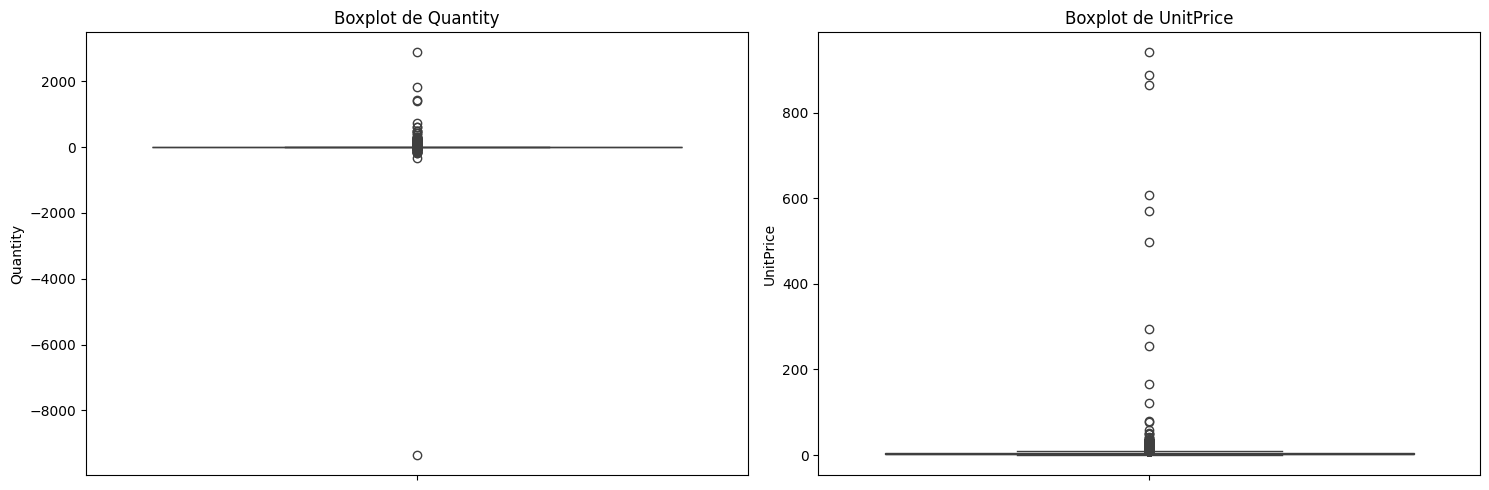

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Quantity'])
plt.title('Boxplot de Quantity')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['UnitPrice'])
plt.title('Boxplot de UnitPrice')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Creamos una copia para no modificar el original
df_limpio = df.copy()

# 2. Limpieza de Nulos y Duplicados
df_limpio = df_limpio.dropna(subset=['Description'])
df_limpio = df_limpio.drop_duplicates()
df_limpio['CustomerID'] = df_limpio['CustomerID'].fillna('sin registro').astype(str)

# 3. Filtros Lógicos (Valores mayores a cero)
df_limpio = df_limpio[(df_limpio['Quantity'] > 0) & (df_limpio['UnitPrice'] > 0)]

# 4. Conversión de Tipos y Nuevas Columnas
df_limpio['InvoiceDate'] = pd.to_datetime(df_limpio['InvoiceDate'])
df_limpio['TotalPrice'] = df_limpio['Quantity'] * df_limpio['UnitPrice']

# 5. Eliminación de Outliers (Valores Atípicos) usando IQR
def quitar_outliers_iqr(df, columnas):
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        # Filtramos la columna actual
        df = df[(df[col] >= limite_inferior) & (df[col] <= limite_superior)]
    return df

# Aplicamos el filtro de outliers a Quantity y UnitPrice
df_limpio = quitar_outliers_iqr(df_limpio, ['Quantity', 'UnitPrice'])

In [ ]:
print(f"Dataset original: {df.shape[0]} filas")


Dataset original: 11704 filas


In [ ]:
print(f"Dataset limpio: {df_limpio.shape[0]} filas")


Dataset limpio: 9273 filas


In [ ]:
print(f"Registros eliminados (nulos, duplicados y outliers): {df.shape[0] - df_limpio.shape[0]}")


Registros eliminados (nulos, duplicados y outliers): 2431


In [ ]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9273 entries, 0 to 11702
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    9273 non-null   object        
 1   StockCode    9273 non-null   object        
 2   Description  9273 non-null   object        
 3   Quantity     9273 non-null   int64         
 4   InvoiceDate  9273 non-null   datetime64[ns]
 5   UnitPrice    9273 non-null   float64       
 6   CustomerID   9273 non-null   object        
 7   Country      9273 non-null   object        
 8   TotalPrice   9273 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 724.5+ KB


In [ ]:
for feature in df_limpio.columns:
    print('Total de valores nulos de', feature, '=', df_limpio[feature].isna().sum())

Total de valores nulos de InvoiceNo = 0
Total de valores nulos de StockCode = 0
Total de valores nulos de Description = 0
Total de valores nulos de Quantity = 0
Total de valores nulos de InvoiceDate = 0
Total de valores nulos de UnitPrice = 0
Total de valores nulos de CustomerID = 0
Total de valores nulos de Country = 0
Total de valores nulos de TotalPrice = 0


In [ ]:
# Cuenta cuántas filas están duplicadas en total
total_duplicados = df_limpio.duplicated().sum()
print(f"Total de filas duplicadas: {total_duplicados}")

Total de filas duplicadas: 0


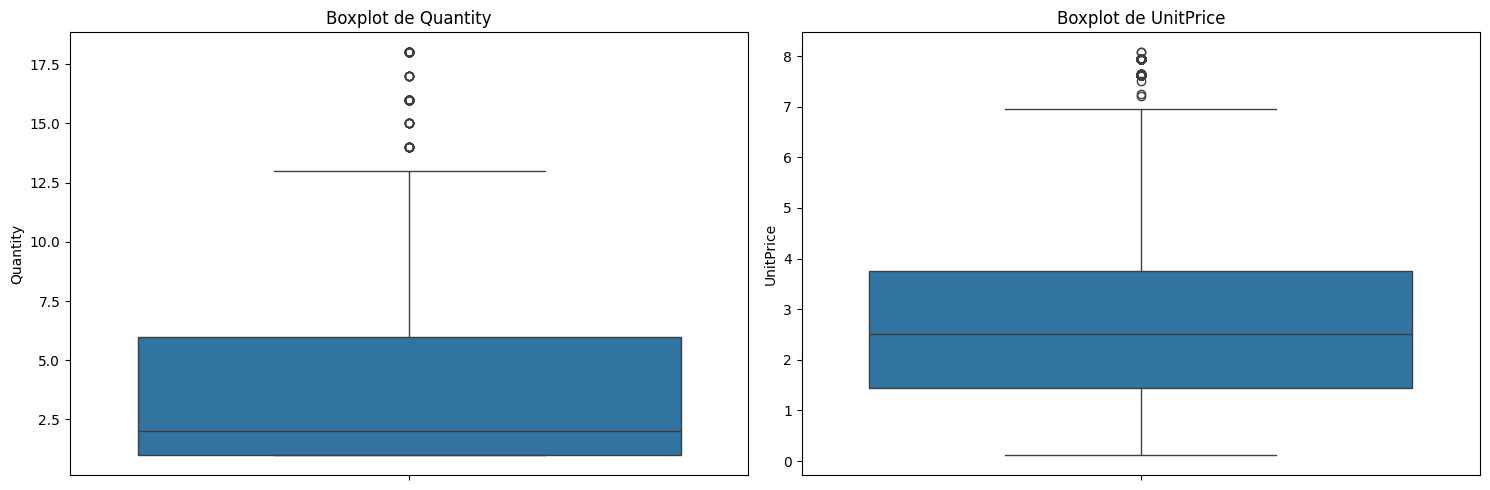

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_limpio['Quantity'])
plt.title('Boxplot de Quantity')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_limpio['UnitPrice'])
plt.title('Boxplot de UnitPrice')

plt.tight_layout()
plt.show()

La Caja Azul: Representa el 50% de tus datos. En Quantity, la mayoría de la gente compra entre 2 y 10 unidades.

En unitprice se concentra entre 1.5 y 4 aproximadamente. El 50% de tus ventas son de productos muy económicos.

# 3.1 Transformaciones y Encoding
- Normalización, estandarización, escalamiento si aplica
- Codificación de variables categóricas (OneHotEncoding, LabelEncoder)
- Selección o ingeniería de características (feature selection/engineering)

## One-Hot Encoding para 'Country'

Para codificar variables categóricas, utilizaremos One-Hot Encoding en la columna `Country`

Es importante mencionar que para el *Market Basket Analysis*, las columnas como `Description` o `StockCode` se transforman en una matriz de transacciones (donde cada fila es una compra y las columnas son los productos, indicando presencia/ausencia) en lugar de un One-Hot Encoding directo sobre todo el dataframe, lo cual se abordará en la sección de modelado o análisis exploratorio.

In [ ]:
# Aplicar One-Hot Encoding a la columna 'Country'
df_limpio = pd.get_dummies(df_limpio, columns=['Country'], prefix='Country')

print("DataFrame después del One-Hot Encoding de 'Country':")
display(df_limpio.head())

DataFrame después del One-Hot Encoding de 'Country':


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Country_Australia,Country_Belgium,...,Country_France,Country_Germany,Country_Italy,Country_Japan,Country_Lithuania,Country_Norway,Country_Poland,Country_Portugal,Country_Switzerland,Country_United Kingdom
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,15.30,False,False,...,False,False,False,False,False,False,False,False,False,True
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,20.34,False,False,...,False,False,False,False,False,False,False,False,False,True
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,22.00,False,False,...,False,False,False,False,False,False,False,False,False,True
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,20.34,False,False,...,False,False,False,False,False,False,False,False,False,True
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,20.34,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
# Mostrar la información actualizada del DataFrame
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9273 entries, 0 to 11702
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   InvoiceNo               9273 non-null   object        
 1   StockCode               9273 non-null   object        
 2   Description             9273 non-null   object        
 3   Quantity                9273 non-null   int64         
 4   InvoiceDate             9273 non-null   datetime64[ns]
 5   UnitPrice               9273 non-null   float64       
 6   CustomerID              9273 non-null   object        
 7   TotalPrice              9273 non-null   float64       
 8   Country_Australia       9273 non-null   bool          
 9   Country_Belgium         9273 non-null   bool          
 10  Country_EIRE            9273 non-null   bool          
 11  Country_France          9273 non-null   bool          
 12  Country_Germany         9273 non-null   bool        

## 4. Análisis Exploratorio
Describa con texto y **agregue gráficos** del análisis.

Estadísticas descriptivas
Visualizaciones significativas: histogramas, boxplots, gráficos de dispersión, mapas de calor, etc.

Hipótesis o tendencias observadas

- Histogramas
- Correlaciones
- Boxplots
- Distribuciones por clase

###Distribución de Variables Numéricas

Vamos a visualizar la distribución de `Quantity`, `UnitPrice` y `TotalPrice` utilizando histogramas para entender mejor la forma de sus datos después de la limpieza y eliminación de outliers.

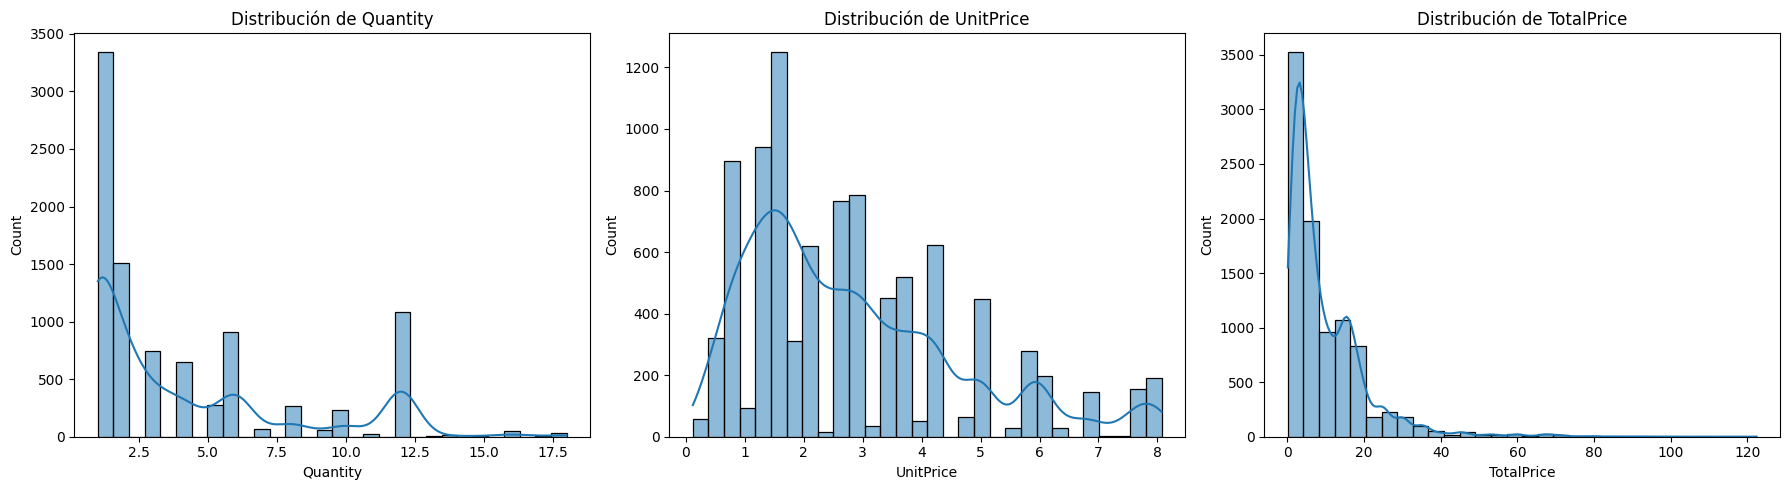

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_limpio['Quantity'], bins=30, kde=True)
plt.title('Distribución de Quantity')

plt.subplot(1, 3, 2)
sns.histplot(df_limpio['UnitPrice'], bins=30, kde=True)
plt.title('Distribución de UnitPrice')

plt.subplot(1, 3, 3)
sns.histplot(df_limpio['TotalPrice'], bins=30, kde=True)
plt.title('Distribución de TotalPrice')

plt.tight_layout()
plt.show()

primer grafico:Analizamos la Cantidad primero porque nos dice cuánto se mueve tu inventario y nos indica que los clientes tienden a comprar en cantidades redondas o por docenas/medias docenas.

segundo grafico:El Precio Unitario nos dice qué precio en los productos vendes. La mayoría de las ventas son de pocas unidades (menos de 5) debe ser de productos económicos. Es más fácil convencer a alguien de agregar un producto de 2 libras (moneda que utiliza la tienda).

tercer grafico: La mayoría de ingresos por línea son pequeños. Esto confirma que para cumplir el objetivo de Optimizar Inventario, es necesario el flujo de salida sea constante, ya que no dependen de unas pocas ventas "caras", sino de miles de ventas "baratas".El stock debe estar preparado para despachar mayoritariamente unidades sueltas o packs de 12.

### Matriz de Correlación: Identificar qué variables se mueven juntas


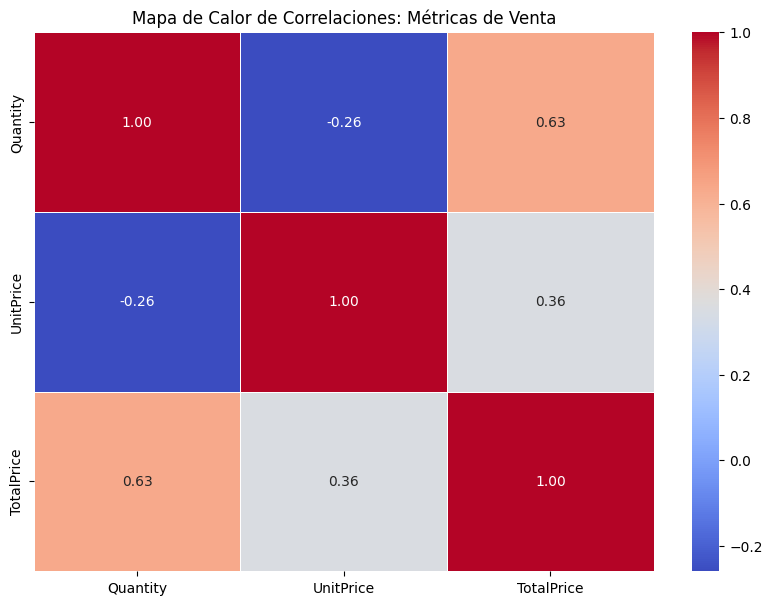

In [ ]:
plt.figure(figsize=(10, 7))

# Seleccionamos solo las columnas numéricas relevantes para que el mapa sea legible
cols_interes = ['Quantity', 'UnitPrice', 'TotalPrice']
correlation_matrix = df_limpio[cols_interes].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones: Métricas de Venta")
plt.show()

La relación Quantity y UnitPrice (-0.35) : A medida que el precio unitario aumenta, la cantidad de productos comprados tiende a disminuir.

La relación Quantity y TotalPrice (0.53): El dinero total que entra depende mucho más de cuántas unidades vendes que de qué tan caras son.

La relación UnitPrice y TotalPrice (0.29): El precio del producto influye en el total, pero no tanto como la cantidad.

### Visualización de Tendencias Temporales

Ahora, visualicemos las ventas (Total Price) a lo largo del tiempo para identificar patrones o tendencias estacionales.

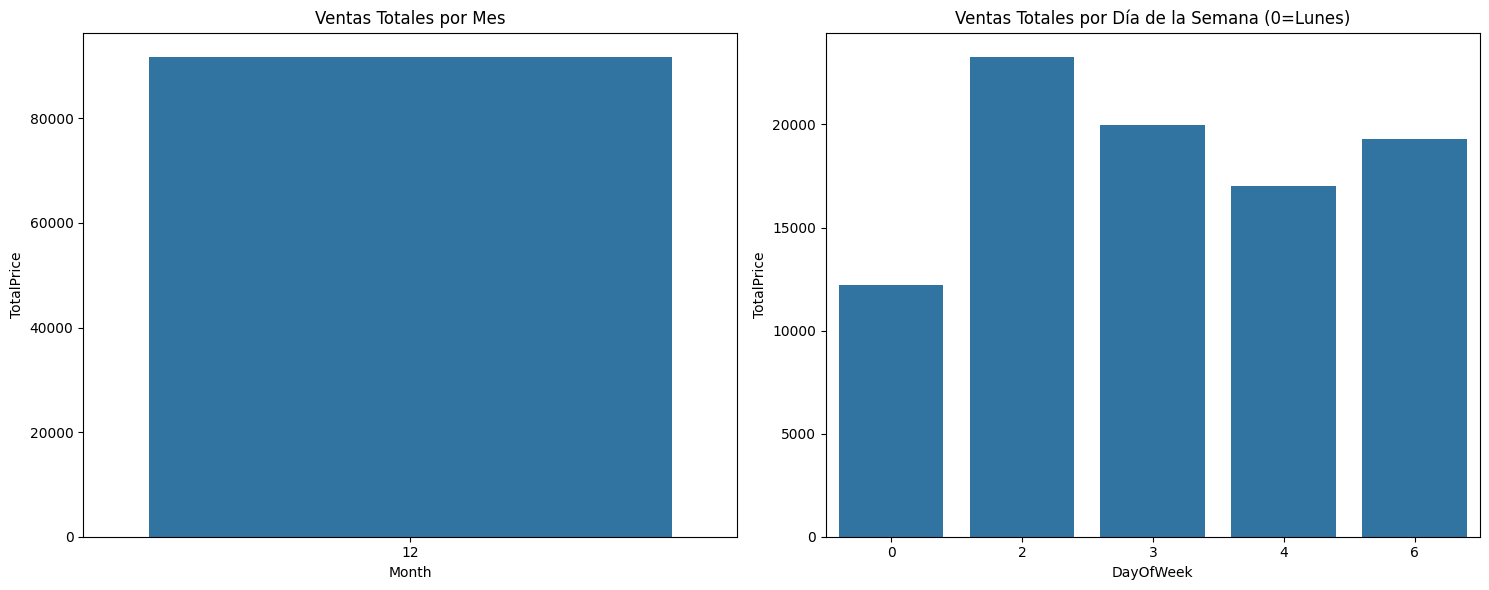

In [ ]:
plt.figure(figsize=(15, 6))

df_limpio['Month'] = df_limpio['InvoiceDate'].dt.month
df_limpio['DayOfWeek'] = df_limpio['InvoiceDate'].dt.dayofweek

plt.subplot(1, 2, 1)
sns.barplot(x='Month', y='TotalPrice', data=df_limpio.groupby('Month')['TotalPrice'].sum().reset_index())
plt.title('Ventas Totales por Mes')

plt.subplot(1, 2, 2)
sns.barplot(x='DayOfWeek', y='TotalPrice', data=df_limpio.groupby('DayOfWeek')['TotalPrice'].sum().reset_index())
plt.title('Ventas Totales por Día de la Semana (0=Lunes)')

plt.tight_layout()
plt.show()

Ventas Totales por Mes: las ventas de Noviembre (Mes 11). Como este es un dataset de retail del Reino Unido, esto refleja claramente la preparación para Navidad (Black Friday, regalos anticipados).

Acción para Inventario: Ahora sabes que en Octubre debes triplicar el stock para no quedarte sin productos en Noviembre o diciembre.

Ventas por Día de la Semana: El día 3 (Jueves) parece ser el punto más alto, mientras que el 5 (Sábado) no aparece.

 Si el jueves es tu día fuerte, podrías lanzar promociones cruzadas el viernes o domingo para incentivar ventas en días "lentos".



## 5. Modelado
Especifique si se trata de clasificación o regresión y qué modelo(s) ha utilizado:

- Regresión lineal / logística
- Árbol de decisión
- KNN / SVM / Random Forest

### a. Tipo de problema
Se trata de un problema de Regresión lineal, ya que el objetivo es predecir una variable numérica continua: la cantidad de productos (Quantity) o el valor de ventas (TotalPrice) que se espera recibir.

### b. Modelo(s) utilizados
Algoritmo seleccionado: Regresión Lineal.

Justificación teórica y empírica: * Teórica: La Regresión Lineal es un modelo fundamental que asume una relación lineal entre las variables independientes y la variable dependiente. Es un excelente punto de partida para comprender las relaciones básicas en los datos debido a su simplicidad y fácil interpretabilidad.

Empírica: Basándonos en el Análisis Exploratorio de Datos identificamos una correlación positiva de `0.53` entre `Quantity` y `TotalPrice`. Esta observación empírica justifica la elección de la Regresión Lineal como modelo inicial, ya que busca capturar esta relación directa para predecir `Quantity` a partir de `TotalPrice`. Proporciona una base sólida para futuros análisis y la exploración de modelos más complejos.

## 6. Entrenamiento y Evaluación
Describa los pasos del entrenamiento del modelo, conjunto de entrenamiento y prueba, métricas utilizadas (Accuracy, RMSE, R², etc.)


### Preparación de Datos para Regresión Lineal

Para el modelo de regresión lineal, seleccionaremos `UnitPrice` como nuestra variable predictora (X) y `Quantity` como nuestra variable objetivo (y). Luego, dividiremos el dataset en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Seleccionar las variables para el modelo de regresión lineal
X = df_limpio[['TotalPrice']]
y = df_limpio[['Quantity']]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 7418 muestras
Tamaño del conjunto de prueba: 1855 muestras


### Entrenamiento del Modelo de Regresión Lineal

Procedemos a entrenar un modelo de `LinearRegression` con los datos de entrenamiento.

In [ ]:
# Inicializar y entrenar el modelo de Regresión Lineal
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

print("Modelo de Regresión Lineal entrenado.")
print(f"Coeficiente (pendiente): {model_lr.coef_[0][0]:.2f}")
print(f"Intercepto: {model_lr.intercept_[0]:.2f}")

Modelo de Regresión Lineal entrenado.
Coeficiente (pendiente): 0.24
Intercepto: 1.83


### Evaluación del Modelo

Evaluaremos el rendimiento del modelo de regresión lineal utilizando métricas comunes como Mean Absolute Error (MAE), Mean Squared Error (MSE) y R-squared (R²).

Mean Absolute Error (MAE): 2.23
Mean Squared Error (MSE): 9.31
Root Mean Squared Error (RMSE): 3.05
R²: 0.38


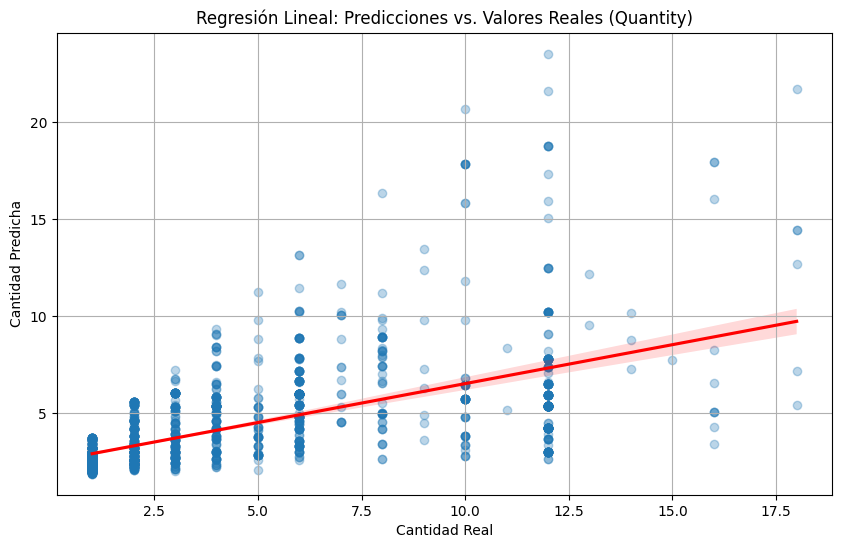

In [ ]:
# Realizar predicciones en el conjunto de prueba
y_pred_lr = model_lr.predict(X_test)

# Calcular métricas de evaluación
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R²: {r2_lr:.2f}")

# Visualizar las predicciones vs. los valores reales
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred_lr, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Regresión Lineal: Predicciones vs. Valores Reales (Quantity)')
plt.xlabel('Cantidad Real')
plt.ylabel('Cantidad Predicha')
plt.grid(True)
plt.show()

### Conclusión de la Regresión Lineal

El modelo de regresión lineal que predice `Quantity` (Cantidad) a partir de `TotalPrice` (Precio Total) muestra un coeficiente (pendiente) de **0.24**, indicando que por cada unidad monetaria adicional en el precio total de una transacción, la cantidad predicha de artículos aumenta en 0.24 unidades. El intercepto de **1.83** representa la cantidad predicha cuando el precio total es cero. Las métricas de evaluación indican un **MAE de 2.23**, **MSE de 9.31** y **RMSE de 3.05**, lo que significa que el error promedio en las predicciones de cantidad es de aproximadamente 2 a 3 unidades. El **R² de 0.38** sugiere que el `TotalPrice` explica un 38% de la variabilidad en `Quantity`, lo que indica que otros factores no incluidos en este modelo simple influyen significativamente en la cantidad comprada.

## 7. Despliegue (opcional)
Explique cómo podría usarse el modelo en una aplicación real o simule un ejemplo.


In [ ]:
# Escriba aqui sus codigos

## 8. Conclusiones
Resumen de hallazgos, utilidad del modelo, recomendaciones futuras.

In [ ]:
# Escriba aqui sus codigos